In [1]:
import sys
import importlib
sys.path.append('../')  # Adjust the path as needed

import utilities.functions as functions
import utilities.plot as plot

# Reload the module to reflect the changes
importlib.reload(functions)
importlib.reload(plot)

<module 'utilities.plot' from '/Users/xuechenkan/potts_model_test/ms1/../utilities/plot.py'>

In [2]:
IN_seq_path = 'IN/data/in.reduce4.seq'
PR_seq_path = 'PR/data/pr.exper.reduce4.seq'    
RT_seq_path = 'RT/data/rt.reduce4.seq'

IN_all_seq = functions.read_seq('IN/data/in.reduce4.seq')
PR_all_seq = functions.read_seq('PR/data/pr.exper.reduce4.seq')
RT_all_seq = functions.read_seq('RT/data/rt.reduce4.seq')

IN_consensus = 'IN/data/in.consensus.reduce4.seq'
with open(IN_consensus, 'r') as f:
    IN_consensus_seq = f.read().strip()
# print("IN consensus sequence:", IN_consensus_seq)
PR_consensus = 'PR/data/pr.consensus.reduce4.seq'
with open(PR_consensus, 'r') as f:
    PR_consensus_seq = f.read().strip()
RT_consensus = 'RT/data/rt.consensus.reduce4.seq'
with open(RT_consensus, 'r') as f:
    RT_consensus_seq = f.read().strip()

# print(IN_consensus_seq)
    
IN_redux = functions.get_redu_dict('IN/data/in.reduce4.redux',1)
PR_redux = functions.get_redu_dict('PR/data/pr.reduce4.redux',0)
RT_redux = functions.get_redu_dict('RT/data/rt.reduce4.redux',0)

IN_J = functions.load_J_dict('IN/data/J.npy',1,263)
PR_J = functions.load_J_dict('PR/data/J_PR.npy',1,99)
RT_J = functions.load_J_dict('RT/data/J_RT.npy',39,226)

IN_all_seq_unreduced = functions.read_seq('IN/data/in.fullseq')
PR_all_seq_unreduced = functions.read_seq('PR/data/pr.exper.fullseq')
RT_all_seq_unreduced = functions.read_seq('RT/data/rt.fullseq')

In [3]:
import pandas as pd

IN_pairs = [
    'G140S-Q148H',
    'Y143C-S230R',
    'G140A-Q148K',
    'G140S-Q148R',
    'G140S-Q148K',
    'G140A-Q148R',
    'E138K-Q148K',
    'G140A-Q148H',
    'E138K-Q148R',
    'Y143C-S230K',
    'N155H-E170A',
    'E138K-S147G',
    'S147G-Q148R',
    'Y143R-V151I',
    'E138K-Q148H',
    'S147G-L158V',
    'E92Q-K215R',
    'E138A-Q148H',
    'E138K-S230K',
    'E138K-Y194C',
]

# convert to reduced alphabet pairs for use with IN_J and reduced consensus/msa
reduced_pairs = functions.pairs_to_reduced(IN_redux, IN_pairs)

results = []
min_pos, max_pos = 1, 263  # Integrase J_dict bounds used when loading IN_J

for unreduced, reduced in zip(IN_pairs, reduced_pairs):
    mut1, mut2 = functions.split_pairs(reduced)
    try:
        de1 = functions.calculate_delta_e(mut1, IN_consensus_seq, IN_J, min_pos, max_pos)
    except Exception:
        de1 = None
    try:
        de2 = functions.calculate_delta_e(mut2, IN_consensus_seq, IN_J, min_pos, max_pos)
    except Exception:
        de2 = None
    try:
        de12 = functions.calculate_delta_e_double(mut1, mut2, IN_consensus_seq, IN_J, min_pos, max_pos)
    except Exception:
        de12 = None
    dde = None
    if de1 is not None and de2 is not None and de12 is not None:
        dde = de12 - de1 - de2
    results.append({
        'pair_unreduced': unreduced,
        'pair_reduced': reduced,
        'deltaE_single_1': de1,
        'deltaE_single_2': de2,
        'deltaE_double': de12,
        'delta_deltaE': dde
    })

df = pd.DataFrame(results)
df.to_csv('IN_double_mutations_DE.csv', index=False)
df

,pair_unreduced,pair_reduced,deltaE_single_1,deltaE_single_2,deltaE_double,delta_deltaE
0,G140S-Q148H,C140D-D148B,-5.728679,-4.553505,-1.773399,8.508784
1,Y143C-S230R,D143A-D230C,-6.367994,-5.990549,-5.981004,6.377539
2,G140A-Q148K,C140A-D148A,-6.462065,-7.125413,-7.974494,5.612984
3,G140S-Q148R,C140D-D148C,-5.728679,-4.153613,-4.678102,5.204190
4,G140S-Q148K,C140D-D148A,-5.728679,-7.125413,-7.670558,5.183534
5,G140A-Q148R,C140A-D148C,-6.462065,-4.153613,-5.700738,4.914940
6,E138K-Q148K,D138A-D148A,-5.789697,-7.125413,-8.014598,4.900512
7,G140A-Q148H,C140A-D148B,-6.462065,-4.553505,-7.260789,3.754781
8,E138K-Q148R,D138A-D148C,-5.789697,-4.153613,-6.417523,3.525786
9,Y143C-S230K,D143A-D230B,-6.367994,-8.044628,-11.379356,3.033266


In [4]:
# print amino acid at position 151 (1-based) from IN consensus
pos = 151
print(f"Position {pos} (1-based):", IN_consensus_seq[pos-1])

Position 151 (1-based): A


In [5]:
PR_pairs = [
    'D30N-N88D',
    'V32I-I47V',
    'G48V-I54A',
    'D30N-K45Q',
    'I54A-V82A',
    'I54V-V82A',
    'M46I-L76V',
    'I54V-V82T',
    'I54A-V82T',
    'G48V-V82A',
    'I54A-A71I',
    'M46I-N88T',
    'L90M-C95F',
    'V32I-M46I',
    'G48V-V82T',
    'I54V-T91S',
    'M46I-F53Y',
    'M46L-K55R',
    'M46L-V82A',
    'M46I-K55R',
]

# convert to reduced alphabet pairs for use with PR_J and reduced consensus/msa
reduced_pairs = functions.pairs_to_reduced(PR_redux, PR_pairs)

results = []
min_pos, max_pos = 1, 99  # Protease J_dict bounds used when loading PR_J

for unreduced, reduced in zip(PR_pairs, reduced_pairs):
    mut1, mut2 = functions.split_pairs(reduced)
    try:
        de1 = functions.calculate_delta_e(mut1, PR_consensus_seq, PR_J, min_pos, max_pos)
    except Exception:
        de1 = None
    try:
        de2 = functions.calculate_delta_e(mut2, PR_consensus_seq, PR_J, min_pos, max_pos)
    except Exception:
        de2 = None
    try:
        de12 = functions.calculate_delta_e_double(mut1, mut2, PR_consensus_seq, PR_J, min_pos, max_pos)
    except Exception:
        de12 = None
    dde = None
    if de1 is not None and de2 is not None and de12 is not None:
        dde = de12 - de1 - de2
    results.append({
        'pair_unreduced': unreduced,
        'pair_reduced': reduced,
        'deltaE_single_1': de1,
        'deltaE_single_2': de2,
        'deltaE_double': de12,
        'delta_deltaE': dde
    })

df_pr = pd.DataFrame(results)
df_pr.to_csv('PR_double_mutations_DE.csv', index=False)
df_pr

,pair_unreduced,pair_reduced,deltaE_single_1,deltaE_single_2,deltaE_double,delta_deltaE
0,D30N-N88D,B30D-B88C,-3.382649,-6.101837,-4.873615,4.610871
1,V32I-I47V,C32D-A47B,-4.815643,-6.037335,-7.402368,3.450611
2,G48V-I54A,B48A-C54A,-5.687656,-8.926517,-11.476565,3.137607
3,D30N-K45Q,B30D-C45D,-3.382649,-7.306343,-7.607358,3.081635
4,I54A-V82A,C54A-C82B,-8.926517,-3.229636,-9.210552,2.945601
5,I54V-V82A,C54D-C82B,-4.856023,-3.229636,-5.223388,2.862272
6,M46I-L76V,C46D-A76C,-3.361691,-6.450879,-7.147024,2.665546
7,I54V-V82T,C54D-C82A,-4.856023,-4.716044,-7.095943,2.476124
8,I54A-V82T,C54A-C82A,-8.926517,-4.716044,-11.298969,2.343592
9,G48V-V82A,B48A-C82B,-5.687656,-3.229636,-6.598114,2.319178


In [6]:
RT_NNRTI_pairs = [
    'K101E-G190S',
    'K101E-G190A',
    'K103N-P225H',
    'L100I-K103N',
    'K101P-K103S',
    'Y181C-H221Y',
    'K103S-G190A',
    'K103S-P225H',
    'L100I-K103R',
    'V108I-H221Y',
    'K103S-D192N',
    'L100I-K103S',
    'K101E-E138A',
    'Y181C-G190A',
    'K103S-D177N',
    'V108I-V189I',
    'K101E-E138K',
    'E138A-G190E',
    'K101P-D192N',
    'V108I-L109V',
]

# convert to reduced alphabet pairs for use with RT_J and reduced consensus/msa
reduced_pairs = functions.pairs_to_reduced(RT_redux, RT_NNRTI_pairs)

results = []
min_pos, max_pos = 39, 226  # RT J_dict bounds used when loading RT_J

for unreduced, reduced in zip(RT_NNRTI_pairs, reduced_pairs):
    mut1, mut2 = functions.split_pairs(reduced)
    try:
        de1 = functions.calculate_delta_e(mut1, RT_consensus_seq, RT_J, min_pos, max_pos)
    except Exception:
        de1 = None
    try:
        de2 = functions.calculate_delta_e(mut2, RT_consensus_seq, RT_J, min_pos, max_pos)
    except Exception:
        de2 = None
    try:
        de12 = functions.calculate_delta_e_double(mut1, mut2, RT_consensus_seq, RT_J, min_pos, max_pos)
    except Exception:
        de12 = None
    dde = None
    if de1 is not None and de2 is not None and de12 is not None:
        dde = de12 - de1 - de2
    results.append({
        'pair_unreduced': unreduced,
        'pair_reduced': reduced,
        'deltaE_single_1': de1,
        'deltaE_single_2': de2,
        'deltaE_double': de12,
        'delta_deltaE': dde
    })

df_rt = pd.DataFrame(results)
df_rt.to_csv('RT_NNRTI_double_mutations_DE.csv', index=False)
df_rt

,pair_unreduced,pair_reduced,deltaE_single_1,deltaE_single_2,deltaE_double,delta_deltaE
0,K101E-G190S,C101A-D190C,-3.861675,-4.183331,-4.741327,3.303678
1,K101E-G190A,C101A-D190B,-3.861675,-3.108841,-4.328133,2.642383
2,K103N-P225H,C103B-D225A,-1.118952,-4.981077,-3.464252,2.635777
3,L100I-K103N,C100B-C103B,-5.426763,-1.118952,-3.957276,2.588439
4,K101P-K103S,C101D-C103D,-5.446384,-4.643891,-7.735484,2.354791
5,Y181C-H221Y,D181A-C221D,-2.765302,-4.235595,-5.238311,1.762587
6,K103S-G190A,C103D-D190B,-4.643891,-3.108841,-6.031111,1.721622
7,K103S-P225H,C103D-D225A,-4.643891,-4.981077,-7.977978,1.646990
8,L100I-K103R,C100B-C103A,-5.426763,-4.430820,-8.368267,1.489316
9,V108I-H221Y,B108C-C221D,-4.285306,-4.235595,-7.034515,1.486386


In [7]:
RT_NRTI_pairs = [
    # 'F116Y-Q151M',
    # 'M41L-T215Y',
    # 'V75I-I132L',
    # 'K70R-K219E',
    # 'D67N-K219Q',
    # 'K70R-K219Q',
    # 'L210W-T215Y',
    # 'F116Y-Q151L',
    # 'K65R-S68N',
    # 'V75I-F77L',
    # 'M41L-T215F',
    # 'D67N-K219E',
    # 'L210W-T215S',
    # 'M41L-T215S',
    # 'D67N-K70R',
    # 'L74V-Y115F',
    # 'L74V-L100I',
    # 'A62V-V75I',
    # 'F116Y-Q151R',
    # 'A62V-V75T',
    'V75I-I132L',
    'F116Y-Q151R',
    'F116Y-Q151L',
    'A62V-V75T',
    'L210W-T215S',
    'M41L-T215S',
    'K65R-S68N',
    'M41L-T215F',
    'K70R-K219E',
    'D67N-K219E',
    'L74V-L100I',
    'L74V-Y115F',
    'D67N-K219Q',
    'K70R-K219Q',
    'A62V-V75I',
    'V75I-F77L',
    'D67N-K70R',
    'M41L-T215Y',
    'L210W-T215Y',
    'F116Y-Q151M'
]

# convert to reduced alphabet pairs for use with RT_J and reduced consensus/msa
reduced_pairs = functions.pairs_to_reduced(RT_redux, RT_NRTI_pairs)

results = []
min_pos, max_pos = 39, 226  # RT J_dict bounds used when loading RT_J

for unreduced, reduced in zip(RT_NRTI_pairs, reduced_pairs):
    mut1, mut2 = functions.split_pairs(reduced)
    try:
        de1 = functions.calculate_delta_e(mut1, RT_consensus_seq, RT_J, min_pos, max_pos)
    except Exception:
        de1 = None
    try:
        de2 = functions.calculate_delta_e(mut2, RT_consensus_seq, RT_J, min_pos, max_pos)
    except Exception:
        de2 = None
    try:
        de12 = functions.calculate_delta_e_double(mut1, mut2, RT_consensus_seq, RT_J, min_pos, max_pos)
    except Exception:
        de12 = None
    dde = None
    if de1 is not None and de2 is not None and de12 is not None:
        dde = de12 - de1 - de2
    results.append({
        'pair_unreduced': unreduced,
        'pair_reduced': reduced,
        'deltaE_single_1': de1,
        'deltaE_single_2': de2,
        'deltaE_double': de12,
        'delta_deltaE': dde
    })

df_rt_nrt = pd.DataFrame(results)
df_rt_nrt.to_csv('RT_NRTI_double_mutations_DE.csv', index=False)
df_rt_nrt

,pair_unreduced,pair_reduced,deltaE_single_1,deltaE_single_2,deltaE_double,delta_deltaE
0,V75I-I132L,A75C-C132D,-5.199460,-6.858479,-9.156986,2.900952
1,F116Y-Q151R,B116C-D151A,-5.772256,-6.335634,-10.113729,1.994161
2,F116Y-Q151L,B116C-D151B,-5.772256,-7.980718,-11.077204,2.675770
3,A62V-V75T,B62D-A75B,-3.683370,-5.566928,-7.301865,1.948433
4,L210W-T215S,A210D-D215A,-5.121403,-4.080306,-6.924728,2.276981
5,M41L-T215S,D41C-D215A,-3.644620,-4.080306,-5.453153,2.271774
6,K65R-S68N,B65C-D68C,-4.030985,-5.892120,-7.295638,2.627468
7,M41L-T215F,D41C-D215B,-3.644620,-4.359179,-5.519097,2.484702
8,K70R-K219E,C70D-C219A,-3.355496,-5.293593,-5.877067,2.772023
9,D67N-K219E,A67D-C219A,-3.629226,-5.293593,-6.540830,2.381989


2984 2984 2984


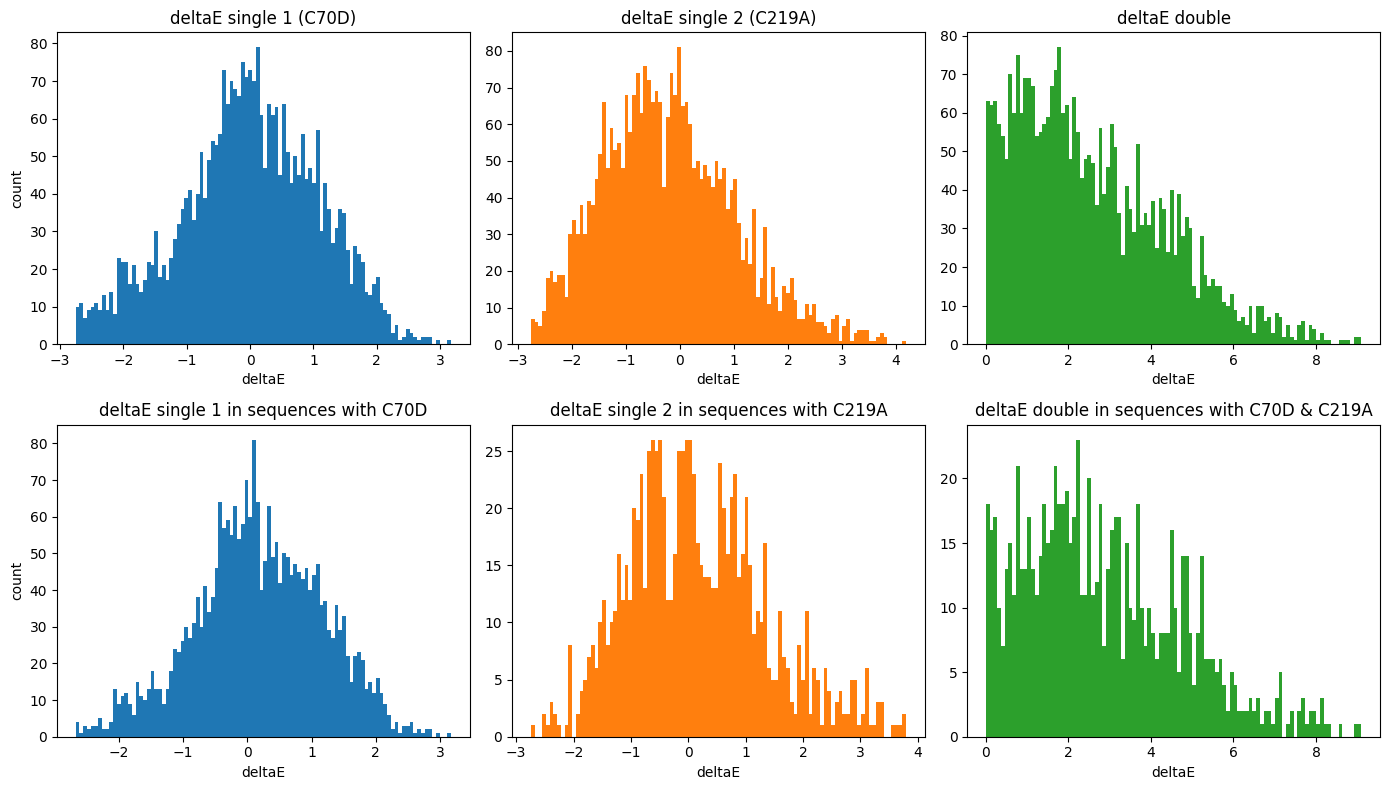

In [26]:
import numpy as np

import matplotlib.pyplot as plt
def gof_test(de1, de2, de12):
    #return true if de12 >de1, de12>de2, and de12>0
    return de12 > de1 and de12 > de2 and de12 > 0
def rescue_test(de1, de2, de12):
    #return true if de12 > de1 and de12 > de2
    return de12 > de1 and de12 > de2 and not gof_test(de1, de2, de12)
def compensatory_test(de1, de2, de12):
    #return true if de12 ? de1 and de12 > de2
    return de12 > de1 or de12 > de2 and not rescue_test(de1, de2, de12)
def non_compensatory_test(de1, de2, de12):
    #return true if none of the above conditions are met
    return not compensatory_test(de1, de2, de12)


# target pair (unreduced)
unreduced = 'K70R-K219E'
reduced = functions.pairs_to_reduced(RT_redux, [unreduced])[0]
mut1, mut2 = functions.split_pairs(reduced)

de1_list, de2_list, de12_list = [], [], []
de1_list_mutation, de2_list_mutation, de12_list_mutation = [], [], []
for seq in RT_all_seq:
    de1, de2, de12, dde = functions.calculate_dde_v2(mut1, mut2, seq, RT_J, min_pos, max_pos)
    if gof_test(de1, de2, de12):
        de1_list.append(de1)
        de2_list.append(de2)
        de12_list.append(de12)
        # check presence of mutations in the reduced sequence and record
        try:
            p1 = int(mut1[1:-1]); m1 = mut1[-1]
            has1 = (min_pos <= p1 <= max_pos) and (seq[p1 - min_pos] == m1)
        except Exception:
            has1 = False
        try:
            p2 = int(mut2[1:-1]); m2 = mut2[-1]
            has2 = (min_pos <= p2 <= max_pos) and (seq[p2 - min_pos] == m2)
        except Exception:
            has2 = False

        if has1:
            de1_list_mutation.append(1)
        if has2:
            de2_list_mutation.append(1)
        if has1 and has2:
            de12_list_mutation.append(1)

# keep only entries that pass gof_test; discard others for plotting

de1 = np.array(de1_list)
de2 = np.array(de2_list)
de12 = np.array(de12_list)
print(len(de1), len(de2), len(de12))

# common bins
all_vals = np.concatenate([de1[~np.isnan(de1)], de2[~np.isnan(de2)], de12[~np.isnan(de12)]])
bins = 100

fig, axes = plt.subplots(2, 3, figsize=(14, 8))

# Histograms (top row)
axes[0,0].hist(de1[~np.isnan(de1)], bins=bins, color='C0')
axes[0,0].set_title(f'deltaE single 1 ({mut1})')
axes[0,0].set_xlabel('deltaE'); axes[0,0].set_ylabel('count')

axes[0,1].hist(de2[~np.isnan(de2)], bins=bins, color='C1')
axes[0,1].set_title(f'deltaE single 2 ({mut2})')
axes[0,1].set_xlabel('deltaE')

axes[0,2].hist(de12[~np.isnan(de12)], bins=bins, color='C2')
axes[0,2].set_title('deltaE double')
axes[0,2].set_xlabel('deltaE')

# DE distributions for sequences with mutation presence (bottom row)
de1_mut_list, de2_mut_list, de12_mut_list = [], [], []
for seq in RT_all_seq:
    de1_v, de2_v, de12_v, _ = functions.calculate_dde_v2(mut1, mut2, seq, RT_J, min_pos, max_pos)
    if not gof_test(de1_v, de2_v, de12_v):
        continue
    try:
        p1 = int(mut1[1:-1]); m1 = mut1[-1]
        has1 = (min_pos <= p1 <= max_pos) and (seq[p1 - min_pos] == m1)
    except Exception:
        has1 = False
    try:
        p2 = int(mut2[1:-1]); m2 = mut2[-1]
        has2 = (min_pos <= p2 <= max_pos) and (seq[p2 - min_pos] == m2)
    except Exception:
        has2 = False

    if has1:
        de1_mut_list.append(de1_v)
    if has2:
        de2_mut_list.append(de2_v)
    if has1 and has2:
        de12_mut_list.append(de12_v)

axes[1,0].hist(np.array(de1_mut_list), bins=bins, color='C0')
axes[1,0].set_title(f'deltaE single 1 in sequences with {mut1}')
axes[1,0].set_xlabel('deltaE'); axes[1,0].set_ylabel('count')

axes[1,1].hist(np.array(de2_mut_list), bins=bins, color='C1')
axes[1,1].set_title(f'deltaE single 2 in sequences with {mut2}')
axes[1,1].set_xlabel('deltaE')

axes[1,2].hist(np.array(de12_mut_list), bins=bins, color='C2')
axes[1,2].set_title(f'deltaE double in sequences with {mut1} & {mut2}')
axes[1,2].set_xlabel('deltaE')

plt.tight_layout()
plt.show()

5605 5605 5605


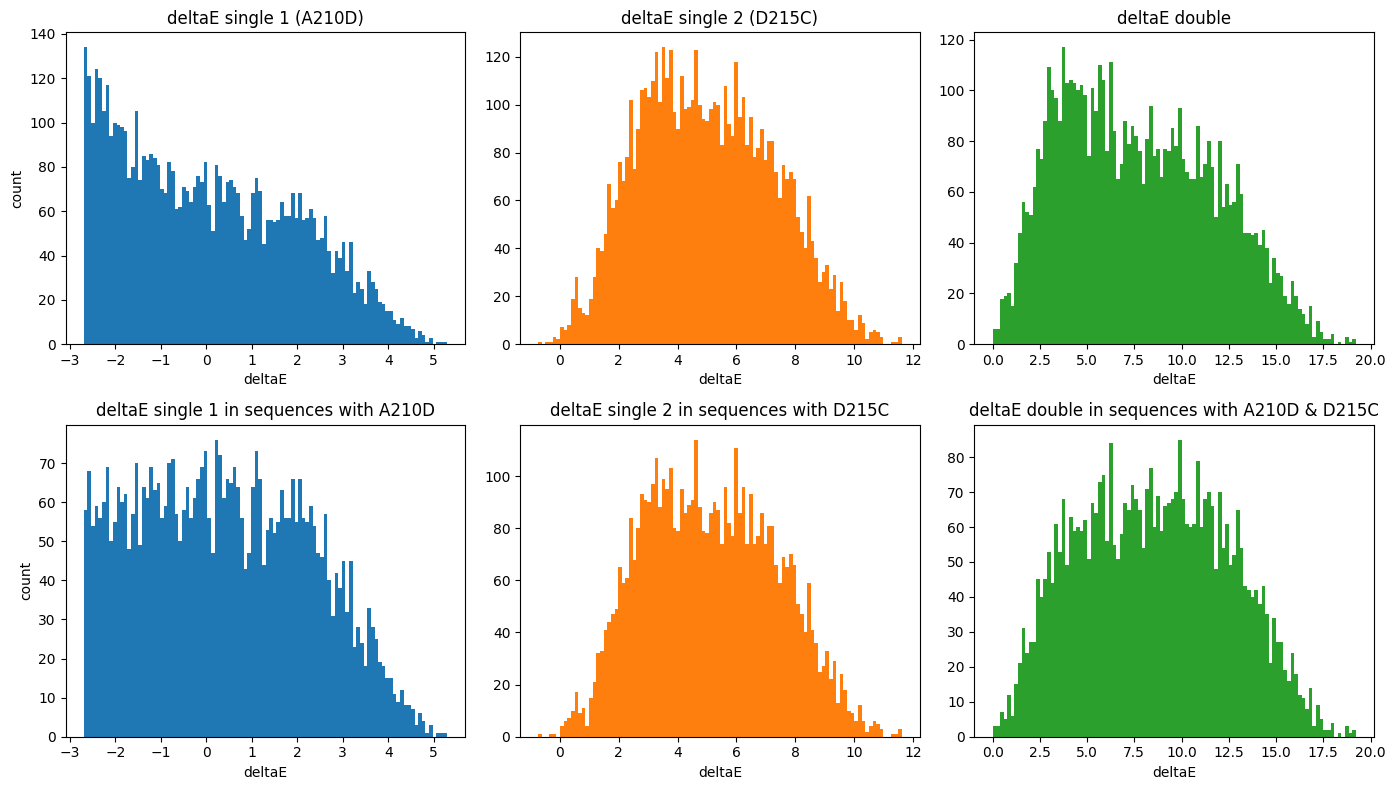

In [29]:
import numpy as np

import matplotlib.pyplot as plt
def gof_test(de1, de2, de12):
    #return true if de12 >de1, de12>de2, and de12>0
    return de12 > de1 and de12 > de2 and de12 > 0
def rescue_test(de1, de2, de12):
    #return true if de12 > de1 and de12 > de2
    return de12 > de1 and de12 > de2 and not gof_test(de1, de2, de12)
def compensatory_test(de1, de2, de12):
    #return true if de12 ? de1 and de12 > de2
    return de12 > de1 or de12 > de2 and not rescue_test(de1, de2, de12)
def non_compensatory_test(de1, de2, de12):
    #return true if none of the above conditions are met
    return not compensatory_test(de1, de2, de12)


# target pair (unreduced)
unreduced = 'L210W-T215H'
reduced = functions.pairs_to_reduced(RT_redux, [unreduced])[0]
mut1, mut2 = functions.split_pairs(reduced)

de1_list, de2_list, de12_list = [], [], []
de1_list_mutation, de2_list_mutation, de12_list_mutation = [], [], []
for seq in RT_all_seq:
    de1, de2, de12, dde = functions.calculate_dde_v2(mut1, mut2, seq, RT_J, min_pos, max_pos)
    if gof_test(de1, de2, de12):
        de1_list.append(de1)
        de2_list.append(de2)
        de12_list.append(de12)
        # check presence of mutations in the reduced sequence and record
        try:
            p1 = int(mut1[1:-1]); m1 = mut1[-1]
            has1 = (min_pos <= p1 <= max_pos) and (seq[p1 - min_pos] == m1)
        except Exception:
            has1 = False
        try:
            p2 = int(mut2[1:-1]); m2 = mut2[-1]
            has2 = (min_pos <= p2 <= max_pos) and (seq[p2 - min_pos] == m2)
        except Exception:
            has2 = False

        if has1:
            de1_list_mutation.append(1)
        if has2:
            de2_list_mutation.append(1)
        if has1 and has2:
            de12_list_mutation.append(1)

# keep only entries that pass gof_test; discard others for plotting

de1 = np.array(de1_list)
de2 = np.array(de2_list)
de12 = np.array(de12_list)
print(len(de1), len(de2), len(de12))

# common bins
all_vals = np.concatenate([de1[~np.isnan(de1)], de2[~np.isnan(de2)], de12[~np.isnan(de12)]])
bins = 100

fig, axes = plt.subplots(2, 3, figsize=(14, 8))

# Histograms (top row)
axes[0,0].hist(de1[~np.isnan(de1)], bins=bins, color='C0')
axes[0,0].set_title(f'deltaE single 1 ({mut1})')
axes[0,0].set_xlabel('deltaE'); axes[0,0].set_ylabel('count')

axes[0,1].hist(de2[~np.isnan(de2)], bins=bins, color='C1')
axes[0,1].set_title(f'deltaE single 2 ({mut2})')
axes[0,1].set_xlabel('deltaE')

axes[0,2].hist(de12[~np.isnan(de12)], bins=bins, color='C2')
axes[0,2].set_title('deltaE double')
axes[0,2].set_xlabel('deltaE')

# DE distributions for sequences with mutation presence (bottom row)
de1_mut_list, de2_mut_list, de12_mut_list = [], [], []
for seq in RT_all_seq:
    de1_v, de2_v, de12_v, _ = functions.calculate_dde_v2(mut1, mut2, seq, RT_J, min_pos, max_pos)
    if not gof_test(de1_v, de2_v, de12_v):
        continue
    try:
        p1 = int(mut1[1:-1]); m1 = mut1[-1]
        has1 = (min_pos <= p1 <= max_pos) and (seq[p1 - min_pos] == m1)
    except Exception:
        has1 = False
    try:
        p2 = int(mut2[1:-1]); m2 = mut2[-1]
        has2 = (min_pos <= p2 <= max_pos) and (seq[p2 - min_pos] == m2)
    except Exception:
        has2 = False

    if has1:
        de1_mut_list.append(de1_v)
    if has2:
        de2_mut_list.append(de2_v)
    if has1 and has2:
        de12_mut_list.append(de12_v)

axes[1,0].hist(np.array(de1_mut_list), bins=bins, color='C0')
axes[1,0].set_title(f'deltaE single 1 in sequences with {mut1}')
axes[1,0].set_xlabel('deltaE'); axes[1,0].set_ylabel('count')

axes[1,1].hist(np.array(de2_mut_list), bins=bins, color='C1')
axes[1,1].set_title(f'deltaE single 2 in sequences with {mut2}')
axes[1,1].set_xlabel('deltaE')

axes[1,2].hist(np.array(de12_mut_list), bins=bins, color='C2')
axes[1,2].set_title(f'deltaE double in sequences with {mut1} & {mut2}')
axes[1,2].set_xlabel('deltaE')

plt.tight_layout()
plt.show()

In [33]:
import numpy as np

import matplotlib.pyplot as plt

def gof_test(de1, de2, de12):
    #return true if de12 >de1, de12>de2, and de12>0
    return de12 > de1 and de12 > de2 and de12 > 0
def rescue_test(de1, de2, de12):
    #return true if de12 > de1 and de12 > de2
    return de12 > de1 and de12 > de2 and not gof_test(de1, de2, de12)
def compensatory_test(de1, de2, de12):
    #return true if de12 ? de1 and de12 > de2
    return de12 > de1 or de12 > de2 and not rescue_test(de1, de2, de12)
def non_compensatory_test(de1, de2, de12):
    #return true if none of the above conditions are met
    return not compensatory_test(de1, de2, de12)


# target pair (unreduced)
unreduced1 = 'L210W-T215S'
reduced = functions.pairs_to_reduced(RT_redux, [unreduced1])[0]
mut1_pair1, mut2_pair1 = functions.split_pairs(reduced)
pair1_indexes = []

unreduced2 = 'L210W-T215Y'
reduced = functions.pairs_to_reduced(RT_redux, [unreduced2])[0]
mut1_pair2, mut2_pair2 = functions.split_pairs(reduced)
pair2_indexes = []

de1_list, de2_list, de12_list = [], [], []
de1_list_mutation, de2_list_mutation, de12_list_mutation = [], [], []

for unreduced in [unreduced1, unreduced2]:
    for iseq, seq in enumerate(RT_all_seq):
        if unreduced == unreduced1:
            mut1, mut2 = mut1_pair1, mut2_pair1
        else:
            mut1, mut2 = mut1_pair2, mut2_pair2
        de1, de2, de12, dde = functions.calculate_dde_v2(mut1, mut2, seq, RT_J, min_pos, max_pos)
        if gof_test(de1, de2, de12):
            if unreduced == unreduced1:
                pair1_indexes.append(iseq)
            else:
                pair2_indexes.append(iseq)

print(f"Pair {unreduced1} indexes count:", len(pair1_indexes))
print(f"Pair {unreduced2} indexes count:", len(pair2_indexes))
print("overlap indexes count:", len(set(pair1_indexes) & set(pair2_indexes)))
# print("overlap indexes:", set(pair1_indexes) & set(pair2_indexes))


Pair L210W-T215S indexes count: 4646
Pair L210W-T215Y indexes count: 5605
overlap indexes count: 4646


In [34]:
import numpy as np

import matplotlib.pyplot as plt

def gof_test(de1, de2, de12):
    #return true if de12 >de1, de12>de2, and de12>0
    return de12 > de1 and de12 > de2 and de12 > 0
def rescue_test(de1, de2, de12):
    #return true if de12 > de1 and de12 > de2
    return de12 > de1 and de12 > de2 and not gof_test(de1, de2, de12)
def compensatory_test(de1, de2, de12):
    #return true if de12 ? de1 and de12 > de2
    return de12 > de1 or de12 > de2 and not rescue_test(de1, de2, de12)
def non_compensatory_test(de1, de2, de12):
    #return true if none of the above conditions are met
    return not compensatory_test(de1, de2, de12)


# target pair (unreduced)
unreduced1 = 'M41L-T215F'
reduced = functions.pairs_to_reduced(RT_redux, [unreduced1])[0]
mut1_pair1, mut2_pair1 = functions.split_pairs(reduced)
pair1_indexes = []

unreduced2 = 'L210W-T215Y'
reduced = functions.pairs_to_reduced(RT_redux, [unreduced2])[0]
mut1_pair2, mut2_pair2 = functions.split_pairs(reduced)
pair2_indexes = []

de1_list, de2_list, de12_list = [], [], []
de1_list_mutation, de2_list_mutation, de12_list_mutation = [], [], []

for unreduced in [unreduced1, unreduced2]:
    for iseq, seq in enumerate(RT_all_seq):
        if unreduced == unreduced1:
            mut1, mut2 = mut1_pair1, mut2_pair1
        else:
            mut1, mut2 = mut1_pair2, mut2_pair2
        de1, de2, de12, dde = functions.calculate_dde_v2(mut1, mut2, seq, RT_J, min_pos, max_pos)
        if gof_test(de1, de2, de12):
            if unreduced == unreduced1:
                pair1_indexes.append(iseq)
            else:
                pair2_indexes.append(iseq)

print(f"Pair {unreduced1} indexes count:", len(pair1_indexes))
print(f"Pair {unreduced2} indexes count:", len(pair2_indexes))
print("overlap indexes count:", len(set(pair1_indexes) & set(pair2_indexes)))
# print("overlap indexes:", set(pair1_indexes) & set(pair2_indexes))


Pair M41L-T215F indexes count: 5617
Pair L210W-T215Y indexes count: 5605
overlap indexes count: 4812
